## Introduction

In this project I will create a model that will forecast the energy consumption of the grid network with a 7 day window. I will first train a model on the DAYTON.csv dataset, then evaulate this on other companies track records to see how the model generalizes. I will use the Mean Squared Error as my error metric.

## Importing libraries

In [ ]:
# basics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# preprocessing
from sklearn.preprocessing import MinMaxScaler

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

## Preprocessing

First I will check whether there are missing values or not. If there is I need to impute them with the timestep t-1 and t+1.

In [2]:
dayton = pd.read_csv("data/DAYTON_hourly.csv")
dayton = dayton.drop(columns="Datetime")

In [3]:
dayton.isna().sum()

DAYTON_MW    0
dtype: int64

Luckily there were no missing values, so I will create the train, validation and test splits from the original dataset.

In [4]:
n = len(dayton)

train_df = dayton.iloc[:int(n*0.7)]
val_df = dayton.iloc[int(n*0.7):int(n*0.85)]
test_df = dayton.iloc[int(n*0.85):]

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)
valid_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

## 1. Predicting the next day consumption Seq2Vec

I will use a window size of 50. Each record is a observation every hour, so 50 hours covers the day before and 2 days before.

In [ ]:
# creating the df objects
window = 50

train_df = tf.keras.utils.timeseries_dataset_from_array(
        data=train_scaled,            # get data from this dataset
        targets=train_scaled[window:], # target comes after 50th step
        sequence_length=window,   # each window will have 50 steps
        sequence_stride=1,        # move the window by 1
        shuffle=True,               
        batch_size=32
)

valid_df = tf.keras.utils.timeseries_dataset_from_array(
        data=valid_scaled[:-1],            
        targets=valid_scaled[window:], 
        sequence_length=window,   
        sequence_stride=1,
        shuffle=False,               
        batch_size=32
)

test_df = tf.keras.utils.timeseries_dataset_from_array(
        data=test_scaled[:-1],            
        targets=test_scaled[window:], 
        sequence_length=window,   
        sequence_stride=1,
        shuffle=False,               
        batch_size=32
)

### Baseline model - Naive forecast - MSE 0.00122

The baseline model is here for comparison. How much better can I build a model when it is compared with Naive Forecast. This rule works by predicting the next days` consumption to be the current days consumption.
- Prediction: t+1 = t

In [7]:
y_true = []
y_pred_naive = []

for x_batch, y_batch in valid_df:
    last_step = x_batch[:, -1, 0].numpy()

    y_pred_naive.extend(last_step)
    y_true.extend(y_batch.numpy().flatten())

naive_mse = np.mean((np.array(y_true) - np.array(y_pred_naive)) ** 2)
print("MSE: ",naive_mse)

MSE:  0.0012217728355270769


2026-09-12 23:31:08.034530: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Linear model - MSE 0.0145 | 1188% error increase compared to baseline 

Next model breaks the previous model`s simple assumption. It tries to find the best coefficent and bias to fit the line to the electricity consumption. However in this problem set it performs worse than the baseline since the 1 timestep prediction window favors the baseline model more. When it comes to 7-day prediction window linear model should surpass the baseline model.

In [380]:
linear_model = keras.models.Sequential([
    keras.layers.Input(shape=(50,1)),
    keras.layers.Dense(1)
])

linear_model.compile(loss="mse", optimizer="adam")

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=5,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10
)

linear_model.fit(train_df, validation_data=valid_df, epochs=50, callbacks=[reduce_lr, early_stop])

Epoch 1/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0189 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 2/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0171 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 3/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0171 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 4/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0171 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 5/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0171 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 6/50
2631/2652 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0171
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0171 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 7/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0171 - val_loss: 0.0170 - learning_rate: 5.0000e-04
Epoch 8/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0171 - val_los

567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0150


(3000.0, 3400.0)

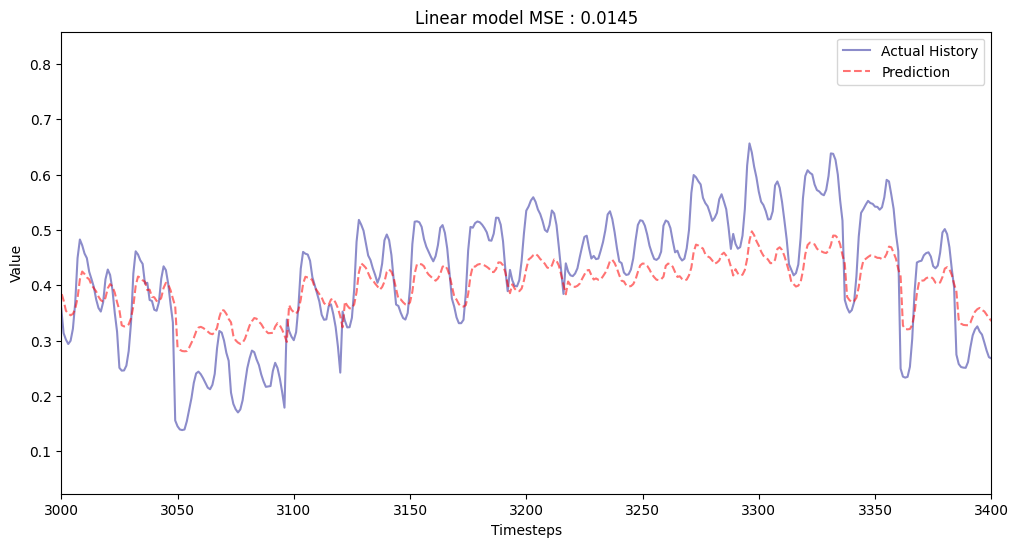

In [381]:
# Squeeze or select the first prediction window: shape becomes (50,)
y_pred = linear_model.predict(test_df)
mse1 = round(linear_model.evaluate(test_df),4)
y_linear_series = y_pred[:, -1, :].flatten()
steps = np.arange(50, len(y_pred)+50, 1)

plt.figure(figsize=[12, 6])
plt.plot(test_scaled, label="Actual History", color="darkblue", alpha=0.45)
plt.plot(steps, y_linear_series, "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"Linear model MSE : {mse1}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(3000, 3400)


### Simple RNN model - MSE 0.0003 | -75.4 % error compared to baseline

The RNN model uses the current input and the previous output from the RNN model, which is called hidden state. Altough it remembers the previous output, it can not understand long term patterns.

In [382]:
model2 = keras.models.Sequential([
    keras.layers.Input(shape=(None,1)),
    keras.layers.SimpleRNN(32),
    keras.layers.Dense(1)
])
model2.compile(loss="mse", optimizer="adam")

model2.fit(train_df, validation_data=valid_df, epochs=20, callbacks=[early_stop, reduce_lr])

Epoch 1/20


2652/2652 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0134 - val_loss: 8.3808e-04 - learning_rate: 0.0010
Epoch 2/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 5.4376e-04 - val_loss: 4.4256e-04 - learning_rate: 0.0010
Epoch 3/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 4.2349e-04 - val_loss: 3.8850e-04 - learning_rate: 0.0010
Epoch 4/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.9556e-04 - val_loss: 3.8006e-04 - learning_rate: 0.0010
Epoch 5/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.8240e-04 - val_loss: 4.0988e-04 - learning_rate: 0.0010
Epoch 6/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.6746e-04 - val_loss: 4.0003e-04 - learning_rate: 0.0010
Epoch 7/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.6973e-04
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.6973e-04 - val_loss: 3.6479e-04 - learning_rate: 0.0010
Epoch 8/20
2652/2652 ━━━━━━━━━━

567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.5228e-04


(0.0, 500.0)

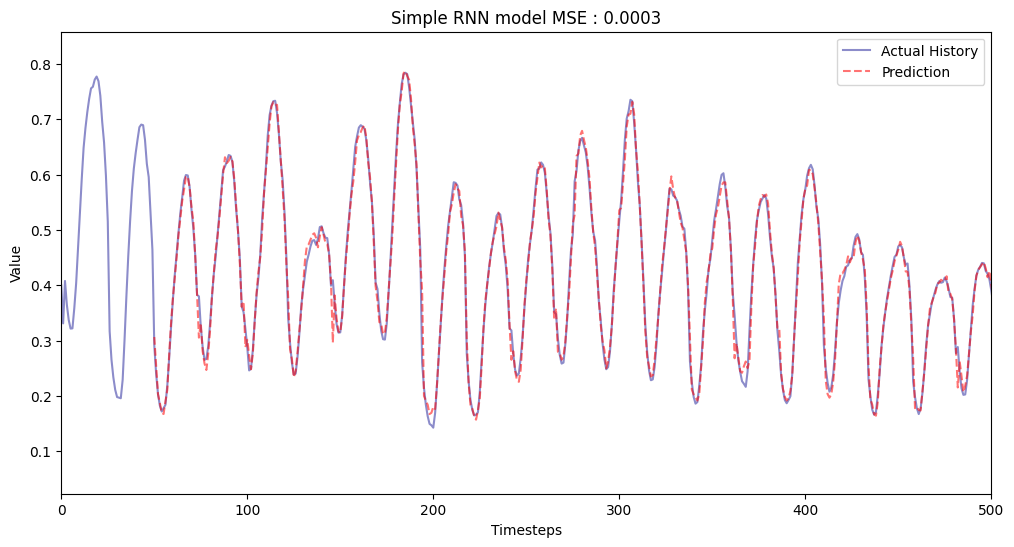

In [383]:
y_pred = model2.predict(test_df)
mse2 = round(model2.evaluate(test_df),4)
y_linear_series = y_pred.flatten()
steps = np.arange(50, len(y_pred)+50, 1)

plt.figure(figsize=[12, 6])
plt.plot(test_scaled, label="Actual History", color="darkblue", alpha=0.45)
plt.plot(steps, y_linear_series, "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"Simple RNN model MSE : {mse2}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(0, 500)

In [58]:
mean_absolute_percentage_error(test_scaled[50:], y_linear_series)

0.03223082655196243

### LSTM model - MSE 0.0003

LSTM fixes RNN simplicity. It includes long and short term memory cell which are capable of remembering longer sequences. This helps the model to better fit to seasonalities and trends.

In [384]:
model3 = keras.models.Sequential([
    keras.layers.Input(shape=[None, 1]),
    keras.layers.LSTM(32),
    keras.layers.Dense(1)
])
model3.compile(loss="mse", optimizer="adam")
model3.fit(train_df, validation_data=valid_df, epochs=20, callbacks=[early_stop, reduce_lr])

Epoch 1/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0070 - val_loss: 6.5058e-04 - learning_rate: 0.0010
Epoch 2/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 6.8371e-04 - val_loss: 6.3915e-04 - learning_rate: 0.0010
Epoch 3/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5.9002e-04 - val_loss: 5.7437e-04 - learning_rate: 0.0010
Epoch 4/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5.0143e-04 - val_loss: 5.2401e-04 - learning_rate: 0.0010
Epoch 5/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 4.2968e-04 - val_loss: 4.3177e-04 - learning_rate: 0.0010
Epoch 6/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 4.0009e-04 - val_loss: 3.9388e-04 - learning_rate: 0.0010
Epoch 7/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 3.7708e-04 - val_loss: 3.9555e-04 - learning_rate: 0.0010
Epoch 8/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 3.6017e-04 - val_loss: 3.6580e-04 - learning_rate: 0.0010
Epoch 9/20
2652/2652 ━━━━━━━━━━━━━━━

567/567 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.4762e-04


(0.0, 500.0)

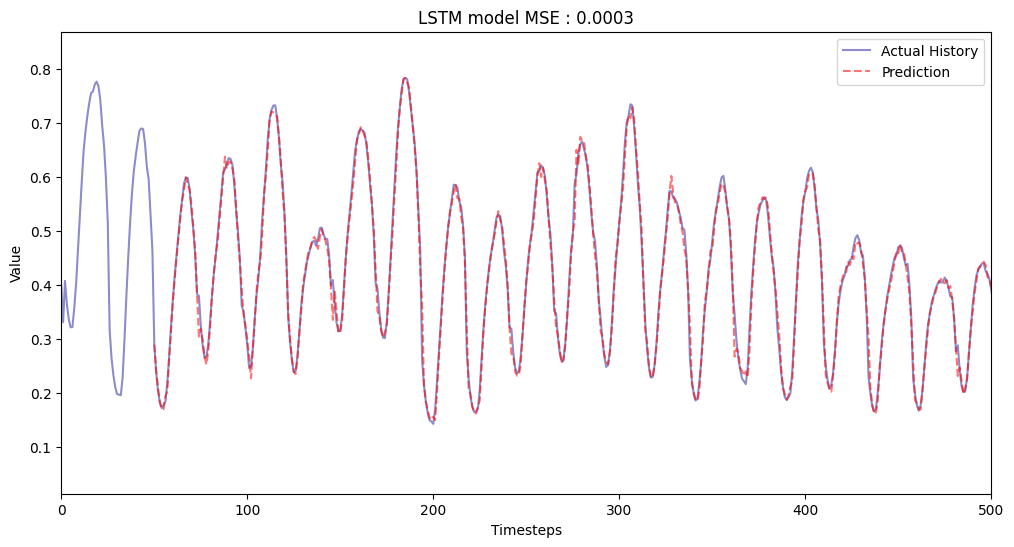

In [385]:
y_pred = model3.predict(test_df)
mse3 = round(model3.evaluate(test_df),4)
y_linear_series = y_pred.flatten()
steps = np.arange(50, len(y_pred)+50, 1)

plt.figure(figsize=[12, 6])
plt.plot(test_scaled, label="Actual History", color="darkblue", alpha=0.45)
plt.plot(steps, y_linear_series, "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"LSTM model MSE : {mse3}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(0, 500)

### GRU model - MSE 0.0003

GRU is a simplified version of LSTM, it also has memory but its faster to train.

In [65]:
model4 = keras.models.Sequential([
    keras.layers.Input(shape=[None, 1]),
    keras.layers.GRU(32),
    keras.layers.Dense(1)
])
model4.compile(loss="mse", optimizer="adam")
model4.fit(train_df, validation_data=valid_df, epochs=20, callbacks=[early_stop, reduce_lr])

Epoch 1/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.0041 - val_loss: 6.5303e-04 - learning_rate: 0.0010
Epoch 2/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 6.9573e-04 - val_loss: 6.5494e-04 - learning_rate: 0.0010
Epoch 3/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 6.6116e-04 - val_loss: 6.0153e-04 - learning_rate: 0.0010
Epoch 4/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5.8438e-04 - val_loss: 5.6223e-04 - learning_rate: 0.0010
Epoch 5/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 4.8469e-04 - val_loss: 5.3710e-04 - learning_rate: 0.0010
Epoch 6/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 4.5263e-04 - val_loss: 4.7256e-04 - learning_rate: 0.0010
Epoch 7/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 4.3074e-04 - val_loss: 4.3544e-04 - learning_rate: 0.0010
Epoch 8/20
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 4.1332e-04 - val_loss: 4.4522e-04 - learning_rate: 0.0010
Epoch 9/20
2652/2652 ━━━━━━━━━━━━━━━

567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.5383e-04


(0.0, 500.0)

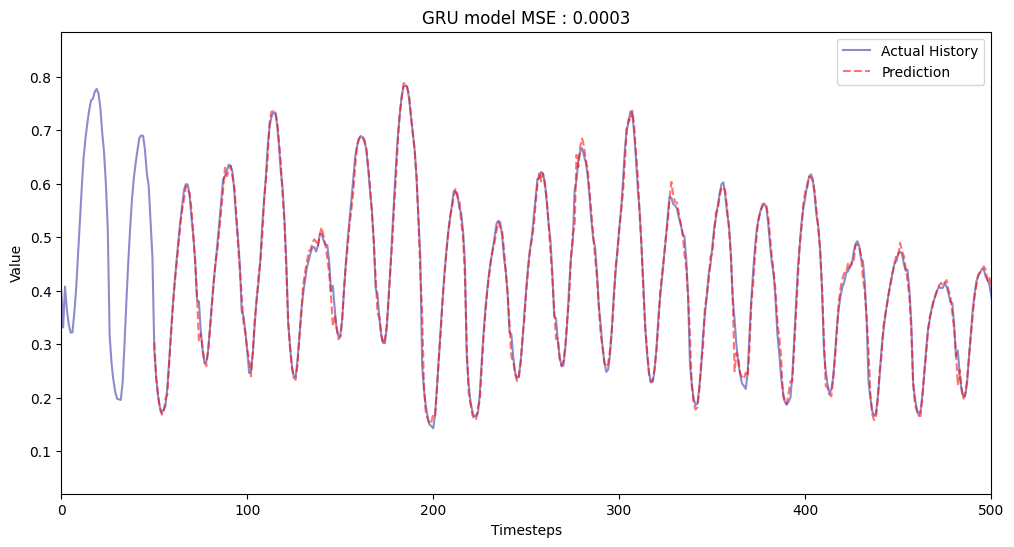

In [66]:
y_pred = model4.predict(test_df)
mse4 = round(model4.evaluate(test_df),4)
y_linear_series = y_pred.flatten()
steps = np.arange(50, len(y_pred)+50, 1)

plt.figure(figsize=[12, 6])
plt.plot(test_scaled, label="Actual History", color="darkblue", alpha=0.45)
plt.plot(steps, y_linear_series, "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"GRU model MSE : {mse4}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(0, 500)

## 2. Predicting the next 7 day consumption -  Seq2Seq model
Reduced baseline error by 90.40% with the final model

First thing to change is the dataframe that we feed into the model. Now this object should allow the model to see 50 steps, and see the targets which are up until step 57. Also change the dense head to TimeDistributed(Dense(7)), this will train the model to output the next 7 days` forecast.

### Creating training, validation and test sets

In [225]:
steps_in = 50
steps_out = 7
total_window_size = steps_in + steps_out 

# 1. Create a dataset of 57-step windows
base_ds_train = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=7,
    shuffle=True,
    batch_size=32
)

base_ds_valid = tf.keras.utils.timeseries_dataset_from_array(
    data=valid_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=7,
    shuffle=False,
    batch_size=32
)

base_ds_test = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=7,
    shuffle=False,
    batch_size=32
)

# 2. Split each batch into X (first 50 steps) and y (next 7 steps)
def split_window(window):
    x = window[:, :steps_in, :]
    y = window[:, steps_in:, :]
    return x, y

train_ds = base_ds_train.map(split_window)
valid_ds = base_ds_valid.map(split_window)
test_ds = base_ds_test.map(split_window)

### Baseline model - Naive forecast - MSE 0.011029

When the model needs to predict the next 7 days from a 50-day window the naive model underperforms severly.

In [388]:
time_stride = 7
y_pred_naive = []
y_actual_naive = []

for x, y in test_ds:
    last_val = x[:, -1, :].numpy()
    naive_forecast = np.repeat(last_val, repeats=time_stride, axis=1)

    y_pred_naive.append(naive_forecast)
    y_actual_naive.append(y.numpy())

y_pred_naive = np.concatenate(y_pred_naive, axis=0).reshape(-1)  
y_actual_naive = np.concatenate(y_actual_naive, axis=0).reshape(-1)

2026-09-13 23:34:08.822521: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


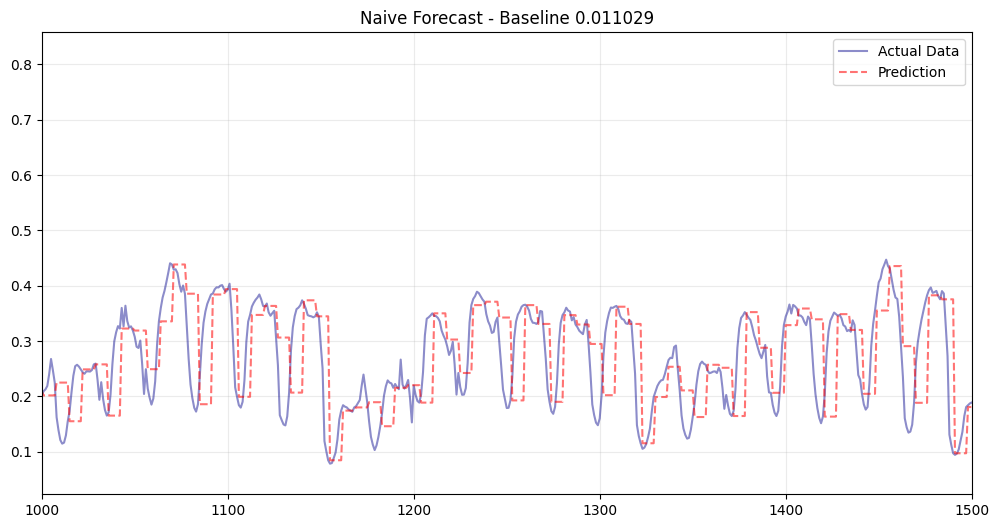

In [389]:
plt.figure(figsize=[12,6])

mse_naive = round(mean_squared_error(y_actual_naive, y_pred_naive),6)
plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(y_pred_naive, "r--", alpha=0.55, label="Prediction")
plt.title(f"Naive Forecast - Baseline {mse_naive}")
plt.xlim(1000,1500)
plt.grid(alpha=0.25)
plt.legend()

### Linear model - MSE 0.002302 | -79.12% error compared to baseline

In [ ]:
linear_model2 = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.Reshape((50,)),
    keras.layers.Dense(7)
])
linear_model2.compile(loss="mse", optimizer="adam")
linear_model2.fit(train_ds, validation_data=valid_ds, epochs=20, callbacks=[early_stop, reduce_lr])

Epoch 1/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1372 - val_loss: 0.0117 - learning_rate: 0.0010
Epoch 2/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - loss: 0.0101 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 3/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0062 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 4/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0048 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 5/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0042 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 6/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0038 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 7/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0035 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 8/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0033 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 9/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0032 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 10

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0023  
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


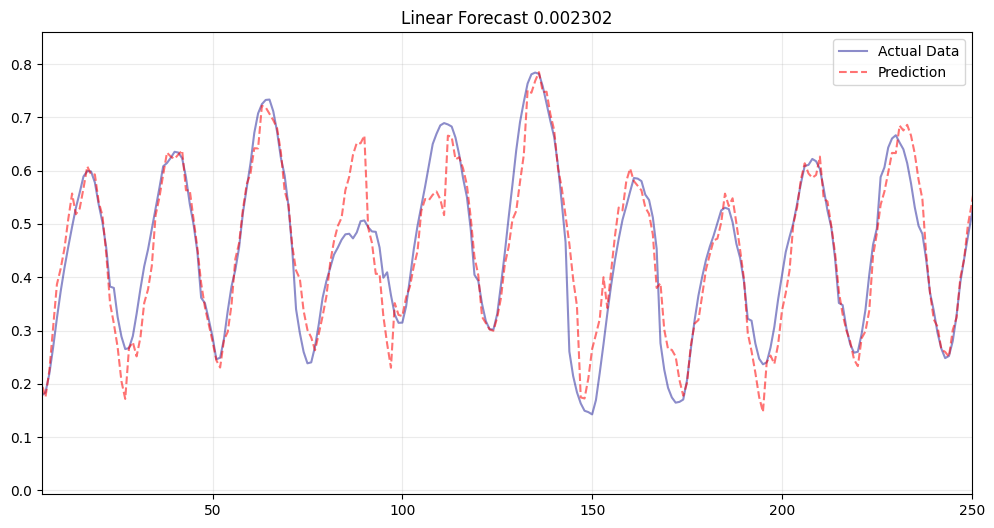

In [262]:
plt.figure(figsize=[12,6])

mse_linear = round(linear_model2.evaluate(test_ds),6)
preds_linear = linear_model2.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_linear, "r--", alpha=0.55, label="Prediction")
plt.title(f"Linear Forecast {mse_linear}")
plt.xlim(5,250)
plt.grid(alpha=0.25)
plt.legend()

### Simple RNN model - MSE 0.001674 | -27.28% error compared to linear model

In [ ]:
srnn_model = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.SimpleRNN(32),
    keras.layers.Dense(7)
])
srnn_model.compile(loss="mse", optimizer="adam")
srnn_model.fit(train_ds, validation_data=valid_ds, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0752 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 2/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0055 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 3/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0044 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 4/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 5/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0032 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 6/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 7/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0027 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 8/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0026 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 9/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0026 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 10/5

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0016
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


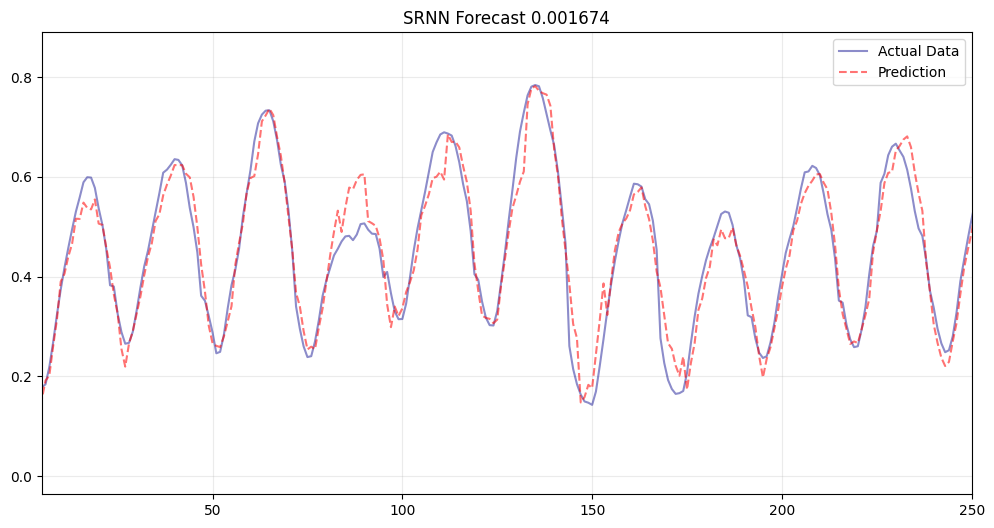

In [263]:
plt.figure(figsize=[12,6])

mse_srnn = round(srnn_model.evaluate(test_ds),6)
preds_srnn = srnn_model.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_srnn, "r--", alpha=0.55, label="Prediction")
plt.title(f"SRNN Forecast {mse_srnn}")
plt.xlim(5,250)
plt.grid(alpha=0.25)
plt.legend()

### GRU model - MSE 0.001619 | -3.28% compared to simple RNN

In [237]:
gru_model = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.GRU(32),
    keras.layers.Dense(7)
])
gru_model.compile(loss="mse", optimizer="adam")
gru_model.fit(train_ds, validation_data=valid_ds, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0448 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 2/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0099 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 3/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0050 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 4/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0045 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 5/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0042 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 6/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0040 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 7/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0038 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 8/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0037 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 9/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0036 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 10/5

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


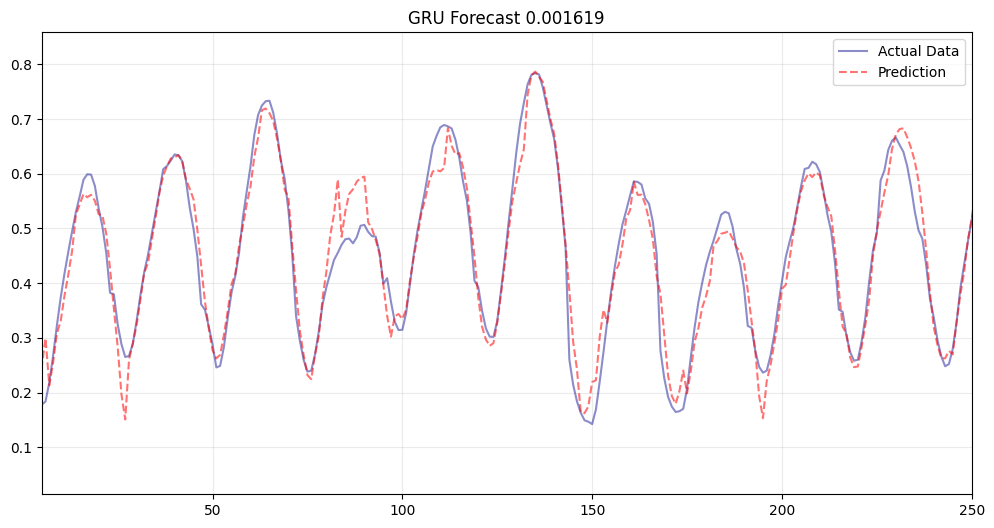

In [265]:
plt.figure(figsize=[12,6])

mse_gru = round(gru_model.evaluate(test_ds),6)
preds_gru = gru_model.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_gru, "r--", alpha=0.55, label="Prediction")
plt.title(f"GRU Forecast {mse_gru}")
plt.xlim(5,250)
plt.grid(alpha=0.25)
plt.legend()

### LSTM - MSE 0.001339 | -17.29% compared to GRU

In [271]:
lstm_model = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.LSTM(32),
    keras.layers.Dense(7)
])

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)

optimizer = keras.optimizers.Adam(learning_rate=1e-2)
lstm_model.compile(loss="mse", optimizer=optimizer)
lstm_model.fit(train_ds, validation_data=valid_ds, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0191 - val_loss: 0.0042 - learning_rate: 0.0100
Epoch 2/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0044 - val_loss: 0.0033 - learning_rate: 0.0100
Epoch 3/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0027 - val_loss: 0.0025 - learning_rate: 0.0100
Epoch 4/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0025 - val_loss: 0.0026 - learning_rate: 0.0100
Epoch 5/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0022 - val_loss: 0.0025 - learning_rate: 0.0100
Epoch 6/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0022 - val_loss: 0.0023 - learning_rate: 0.0100
Epoch 7/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0019 - val_loss: 0.0025 - learning_rate: 0.0100
Epoch 8/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0020 - val_loss: 0.0023 - learning_rate: 0.0100
Epoch 9/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0018 - val_loss: 0.0021 - learning_rate: 0.0100
Epoch 10/5

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0012
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


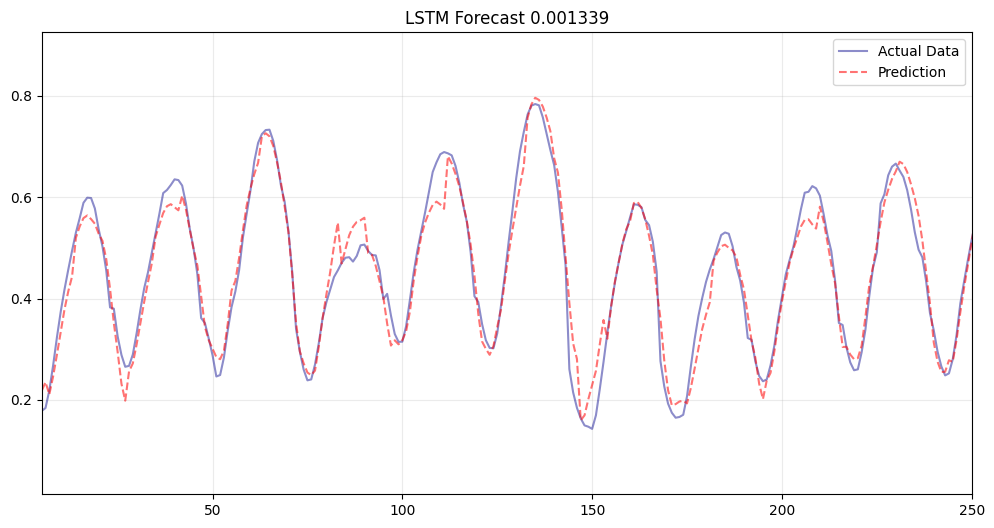

In [272]:
plt.figure(figsize=[12,6])

mse_lstm = round(lstm_model.evaluate(test_ds),6)
preds_lstm = lstm_model.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_lstm, "r--", alpha=0.55, label="Prediction")
plt.title(f"LSTM Forecast {mse_lstm}")
plt.xlim(5,250)
plt.grid(alpha=0.25)
plt.legend()

### Deep LSTM model - MSE 0.001058 | -20.98% compared to LSTM

In [257]:
lstm_model1 = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.LSTM(32),
    keras.layers.Dense(7)
])

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)

optimizer = keras.optimizers.Adam(learning_rate=1e-2)
lstm_model1.compile(loss="mse", optimizer=optimizer)
lstm_model1.fit(train_ds, validation_data=valid_ds, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0186 - val_loss: 0.0045 - learning_rate: 0.0100
Epoch 2/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0036 - val_loss: 0.0026 - learning_rate: 0.0100
Epoch 3/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 0.0100
Epoch 4/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0020 - val_loss: 0.0025 - learning_rate: 0.0100
Epoch 5/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0020 - val_loss: 0.0021 - learning_rate: 0.0100
Epoch 6/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0017 - val_loss: 0.0019 - learning_rate: 0.0100
Epoch 7/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0016 - val_loss: 0.0023 - learning_rate: 0.0100
Epoch 8/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0016 - val_loss: 0.0019 - learning_rate: 0.0100
Epoch 9/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0016 - val_loss: 0.0017 - learning_rate: 0.0100


81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.9375e-04
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


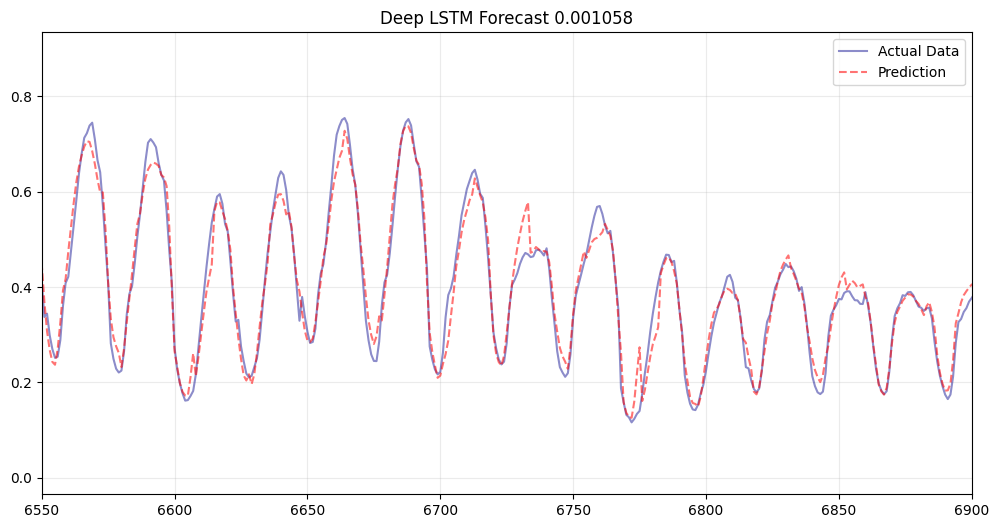

In [268]:
plt.figure(figsize=[12,6])

mse_deep = round(lstm_model1.evaluate(test_ds),6)
preds_deep = lstm_model1.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_deep, "r--", alpha=0.55, label="Prediction")
plt.title(f"Deep LSTM Forecast {mse_deep}")
plt.xlim(6550,6900)
plt.grid(alpha=0.25)
plt.legend()

## 3. Predicting next 7 days with stride of 1

In [386]:
steps_in = 50
steps_out = 7
total_window_size = steps_in + steps_out 

# 1. Create a dataset of 57-step windows
base_ds_train_dense = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
)

base_ds_valid_dense = tf.keras.utils.timeseries_dataset_from_array(
    data=valid_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
)

base_ds_test_dense = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
)

# 2. Split each batch into X (first 50 steps) and y (next 7 steps)
def split_window(window):
    x = window[:, :steps_in, :]
    y = window[:, steps_in:, :]
    return x, y

train_ds_dense = base_ds_train_dense.map(split_window)
valid_ds_dense = base_ds_valid_dense.map(split_window)
test_ds_dense = base_ds_test_dense.map(split_window)

In [387]:
lstm_model1 = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.LSTM(32),
    keras.layers.Dense(7)
])

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)

optimizer = keras.optimizers.Adam(learning_rate=1e-2)
lstm_model1.compile(loss="mse", optimizer=optimizer, metrics=["mae"])
lstm_model1.fit(train_ds_dense, validation_data=valid_ds_dense, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 69s 26ms/step - loss: 0.0066 - mae: 0.0552 - val_loss: 0.0021 - val_mae: 0.0335 - learning_rate: 0.0100
Epoch 2/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 68s 26ms/step - loss: 0.0017 - mae: 0.0300 - val_loss: 0.0015 - val_mae: 0.0276 - learning_rate: 0.0100
Epoch 3/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 68s 26ms/step - loss: 0.0014 - mae: 0.0270 - val_loss: 0.0013 - val_mae: 0.0257 - learning_rate: 0.0100
Epoch 4/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 69s 26ms/step - loss: 0.0012 - mae: 0.0250 - val_loss: 0.0013 - val_mae: 0.0252 - learning_rate: 0.0100
Epoch 5/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 65s 24ms/step - loss: 0.0011 - mae: 0.0236 - val_loss: 0.0011 - val_mae: 0.0236 - learning_rate: 0.0100
Epoch 6/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 65s 24ms/step - loss: 0.0010 - mae: 0.0226 - val_loss: 0.0011 - val_mae: 0.0231 - learning_rate: 0.0100
Epoch 7/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 65s 24ms/step - loss: 9.4294e-04 - mae: 0.0216 - val_loss: 0.0011 - val_mae: 0.023

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.1956e-04 - mae: 0.0181
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


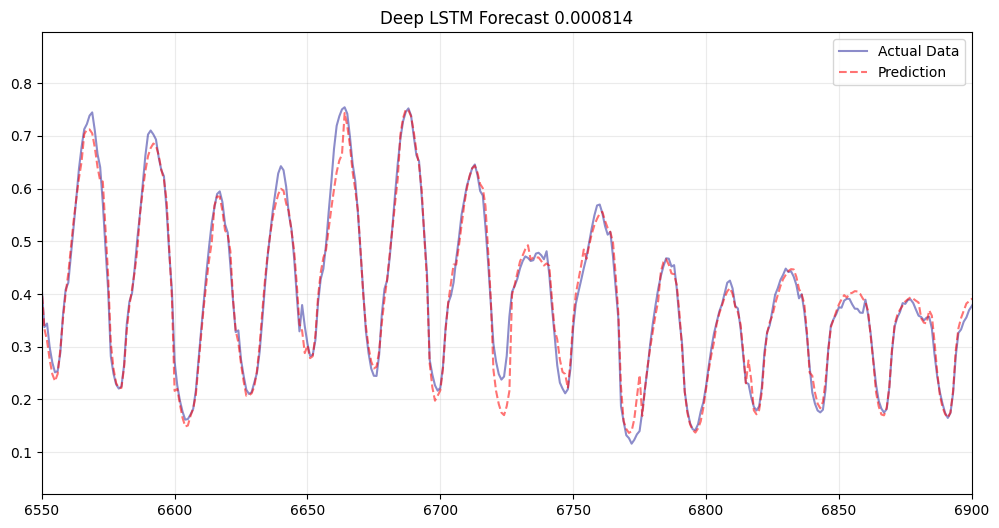

In [390]:
plt.figure(figsize=[12,6])

mse_deep = round(lstm_model1.evaluate(test_ds)[0],6)
preds_deep = lstm_model1.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_deep, "r--", alpha=0.55, label="Prediction")
plt.title(f"Deep LSTM Forecast {mse_deep}")
plt.xlim(6550,6900)
plt.grid(alpha=0.25)
plt.legend()

## 4. Predicting on unseen data for different electricity provider

In [343]:
aep = pd.read_csv("data/AEP_hourly.csv")
aep = aep.drop(columns=["Datetime"])

In [344]:
n_aep = len(aep)

train_df_aep = dayton.iloc[:int(n_aep*0.5)]
val_df_aep = dayton.iloc[int(n_aep*0.5):int(n_aep*0.85)]
test_df_aep = dayton.iloc[int(n_aep*0.85):]

scaler_aep = MinMaxScaler()

train_scaled_aep = scaler_aep.fit_transform(train_df_aep)
valid_scaled_aep = scaler_aep.transform(val_df_aep)
test_scaled_aep = scaler_aep.transform(test_df_aep)

In [345]:
steps_in = 50
steps_out = 7
total_window_size = steps_in + steps_out 

# 1. Create a dataset of 57-step windows
aep_ds_train = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled_aep,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=7,
    shuffle=True,
    batch_size=32
)

aep_ds_valid = tf.keras.utils.timeseries_dataset_from_array(
    data=valid_scaled_aep,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=7,
    shuffle=False,
    batch_size=32
)

aep_ds_test = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled_aep,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=7,
    shuffle=False,
    batch_size=32
)

# 2. Split each batch into X (first 50 steps) and y (next 7 steps)
def split_window(window):
    x = window[:, :steps_in, :]
    y = window[:, steps_in:, :]
    return x, y

train_ds_aep = aep_ds_train.map(split_window)
valid_ds_aep = aep_ds_valid.map(split_window)
test_ds_aep = aep_ds_test.map(split_window)

In [346]:
y_actual_test_aep = []

for x, y in test_ds_aep:
    y_actual_test_aep.append(y.numpy())

# Stack all batches along the batch dimension (axis 0)
y_actual_test_aep = np.concatenate(y_actual_test_aep, axis=0).reshape(-1)



2026-09-13 14:38:40.998868: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.3624e-04 - mae: 0.0182


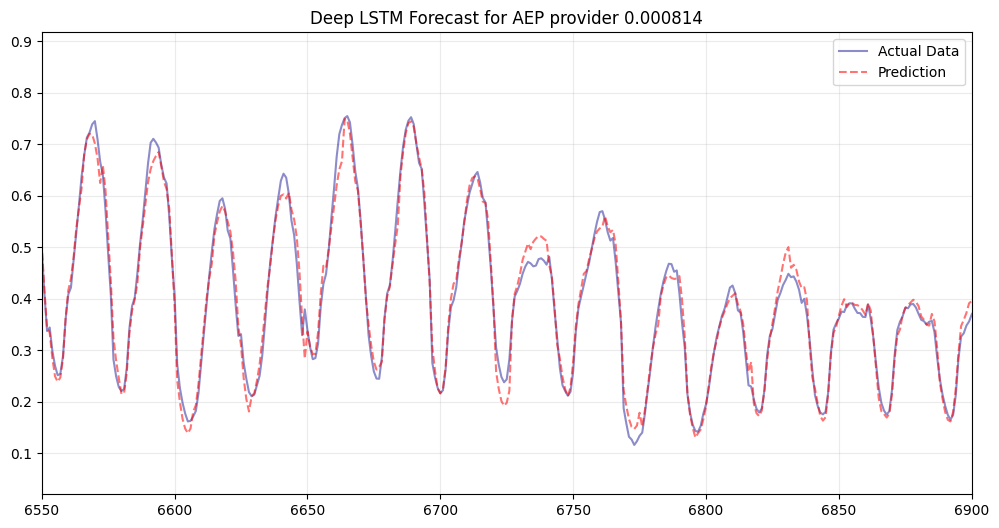

In [348]:
plt.figure(figsize=[12,6])
y_aep_test = lstm_model1.predict(test_ds_aep).reshape(-1)
mse_aep = round(lstm_model1.evaluate(test_ds_aep)[0], 6)


plt.plot(y_actual_test_aep,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(y_aep_test, "r--", alpha=0.55, label="Prediction")
plt.title(f"Deep LSTM Forecast for AEP provider {mse_aep}")
plt.xlim(6550,6900)
plt.grid(alpha=0.25)
plt.legend()

In [332]:
steps_in = 50
steps_out = 7
total_window_size = steps_in + steps_out 

# 1. Create a dataset of 57-step windows
base_ds_train_dense = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
)

base_ds_valid_dense = tf.keras.utils.timeseries_dataset_from_array(
    data=valid_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
)

base_ds_test_dense = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
)

# 2. Split each batch into X (first 50 steps) and y (next 7 steps)
def split_window(window):
    x = window[:, :steps_in, :]
    y = window[:, steps_in:, :]
    return x, y

train_ds_dense = base_ds_train_dense.map(split_window)
valid_ds_dense = base_ds_valid_dense.map(split_window)
test_ds_dense = base_ds_test_dense.map(split_window)

In [336]:
lstm_model1 = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.LSTM(32),
    keras.layers.Dense(7)
])

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)

optimizer = keras.optimizers.Adam(learning_rate=1e-2)
lstm_model1.compile(loss="mse", optimizer=optimizer, metrics=["mae"])
lstm_model1.fit(train_ds_dense, validation_data=valid_ds_dense, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 62s 23ms/step - loss: 0.0076 - mae: 0.0586 - val_loss: 0.0018 - val_mae: 0.0310 - learning_rate: 0.0100
Epoch 2/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 60s 23ms/step - loss: 0.0017 - mae: 0.0297 - val_loss: 0.0017 - val_mae: 0.0290 - learning_rate: 0.0100
Epoch 3/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 60s 23ms/step - loss: 0.0013 - mae: 0.0258 - val_loss: 0.0013 - val_mae: 0.0260 - learning_rate: 0.0100
Epoch 4/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 61s 23ms/step - loss: 0.0011 - mae: 0.0239 - val_loss: 0.0012 - val_mae: 0.0255 - learning_rate: 0.0100
Epoch 5/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 61s 23ms/step - loss: 9.8965e-04 - mae: 0.0223 - val_loss: 0.0013 - val_mae: 0.0259 - learning_rate: 0.0100
Epoch 6/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 61s 23ms/step - loss: 9.6005e-04 - mae: 0.0218 - val_loss: 0.0011 - val_mae: 0.0230 - learning_rate: 0.0100
Epoch 7/50
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 61s 23ms/step - loss: 8.6039e-04 - mae: 0.0205 - val_loss: 0.0012 - val_ma

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.4768e-04 - mae: 0.0183
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


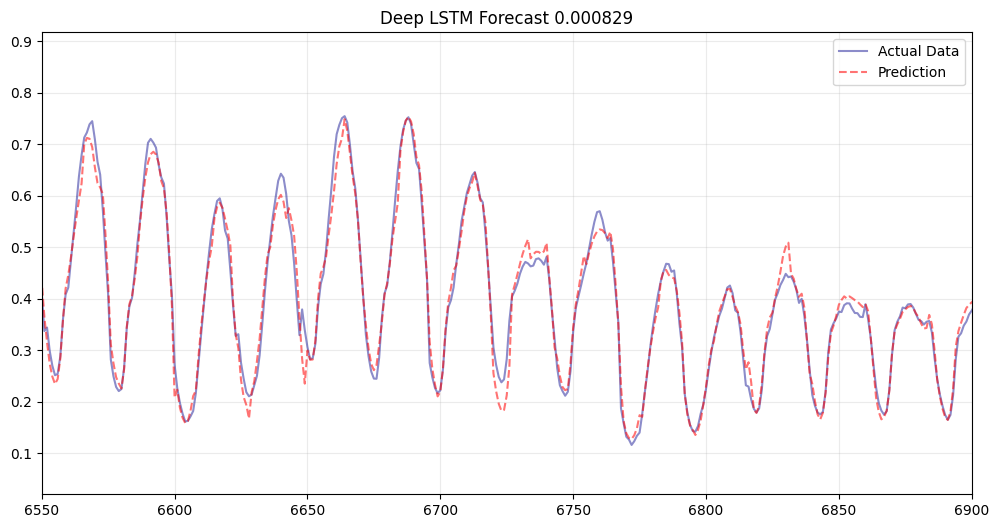

In [349]:
plt.figure(figsize=[12,6])

mse_deep = round(lstm_model1.evaluate(test_ds)[0],6)
preds_deep = lstm_model1.predict(test_ds).reshape(-1)

plt.plot(y_actual_naive ,color="darkblue", alpha=0.45, label="Actual Data")
plt.plot(preds_deep, "r--", alpha=0.55, label="Prediction")
plt.title(f"Deep LSTM Forecast {mse_deep}")
plt.xlim(6550,6900)
plt.grid(alpha=0.25)
plt.legend()